# Optimal Transport in linear ICA

#### In this notebook we test the performance scaling of a OT ICA on Stiefel Manifold versus Fast ICA over dimensions on a mixture consisting only continous laplace distribution.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import FastICA
from tqdm.notebook import tqdm
import time
from joblib import Parallel, delayed
from matplotlib.ticker import MultipleLocator
from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# Thesis Theme Configuration
# ==========================================
def set_thesis_theme():
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    plt.rcParams.update({
        'figure.figsize': (10, 6),
        'figure.dpi': 300,
        'axes.prop_cycle': plt.cycler(color=thesis_colors),
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.frameon': True,
        'legend.fontsize': 11,
        'lines.linewidth': 2.5
    })
set_thesis_theme()

In [3]:
# ==========================================
# 1. Helpers & Data Generation
# ==========================================
def amari_error(W_est, A_true):
    if W_est is None or np.any(np.isnan(W_est)): return np.nan
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    term1 = np.sum((np.sum(P, axis=1) / np.max(P, axis=1)) - 1)
    term2 = np.sum((np.sum(P, axis=0) / np.max(P, axis=0)) - 1)
    return (term1 + term2) / (2 * n)

def generate_dataset(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
    # Standard Laplace (Super-Gaussian)
    sources = [np.random.laplace(0, 1, n_samples) for _ in range(n_dim)]
    S = np.stack(sources)
    
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
    return torch.tensor(A @ S, dtype=torch.float32), A

In [4]:
# ==========================================
# 2. Parallel Worker Function
# ==========================================
def run_single_trial(dim, trial, n_samples, compute_level):
    torch.set_num_threads(1)
    trial_results = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    X_torch, A_true = generate_dataset(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    X_np = X_torch.cpu().numpy()
    
    # Compute Parameters
    if compute_level == 'Low Compute':
        fast_max_iter = 1000
        w2_restarts = min(dim * 4, 150)
        w2_def_iter = 150
        w2_sym_iter = 200
    else: # High Compute
        fast_max_iter = 5000
        w2_restarts = min(dim * 15, 600)
        w2_def_iter = 300
        w2_sym_iter = 500

    # --- FastICA ---
    t0_fast = time.perf_counter()
    try:
        import warnings
        from sklearn.exceptions import ConvergenceWarning
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            fast_ica = FastICA(n_components=dim, max_iter=fast_max_iter, tol=1e-4, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast_total = fast_ica.components_
            score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
    t_fast_total = time.perf_counter() - t0_fast
        
    trial_results.append({
        'Dimension': dim, 'Method': 'FastICA', 'Compute Level': compute_level,
        'Amari Error': score_fast, 'Total Time (s)': t_fast_total
    })
    
    # --- OT-ICA ---
    ica = WassersteinICA(X_torch)
    ica.whiten()
    W_white_np = ica.W_white.cpu().numpy()
    
    try:
        t0_p1 = time.perf_counter()
        extracted_ws = []
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, max_iter=w2_def_iter, 
                n_restarts=w2_restarts, dither_sigma=0.0
            )
            extracted_ws.append(w)
        W_deflation_init = torch.stack(extracted_ws)
        t_phase1 = time.perf_counter() - t0_p1
        
        t0_p2 = time.perf_counter()
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, max_iter=w2_sym_iter, lr=1.0, 
            init_w=W_deflation_init, optimizer='stiefel',
            dither_sigma=0.0, batch_size=None
        )
        t_phase2 = time.perf_counter() - t0_p2
        
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
    except Exception:
        score_wass, t_phase1, t_phase2 = np.nan, np.nan, np.nan
        
    trial_results.append({
        'Dimension': dim, 'Method': 'OT-ICA', 'Compute Level': compute_level,
        'Amari Error': score_wass, 
        'Total Time (s)': t_phase1 + t_phase2 if not np.isnan(t_phase1) else np.nan
    })
    
    return trial_results

In [5]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = [n for n in range(10, 71, 5)] # Scaled up to 40 for good visualization
N_SAMPLES = 10000
COMPUTE_LEVELS = ['Low Compute', 'High Compute']
N_TRIALS = 3

print(f"--- FastICA vs. OT-ICA: Laplace Scaling ---")
tasks = [(dim, trial, N_SAMPLES, comp) for dim in DIMENSIONS for trial in range(N_TRIALS) for comp in COMPUTE_LEVELS]

results_nested = Parallel(n_jobs=12)(
    delayed(run_single_trial)(dim, trial, n_samples, comp) 
    for dim, trial, n_samples, comp in tqdm(tasks, desc="Running Trials")
)
df = pd.DataFrame([item for sublist in results_nested for item in sublist])

--- FastICA vs. OT-ICA: Laplace Scaling ---


Running Trials:   0%|          | 0/78 [00:00<?, ?it/s]

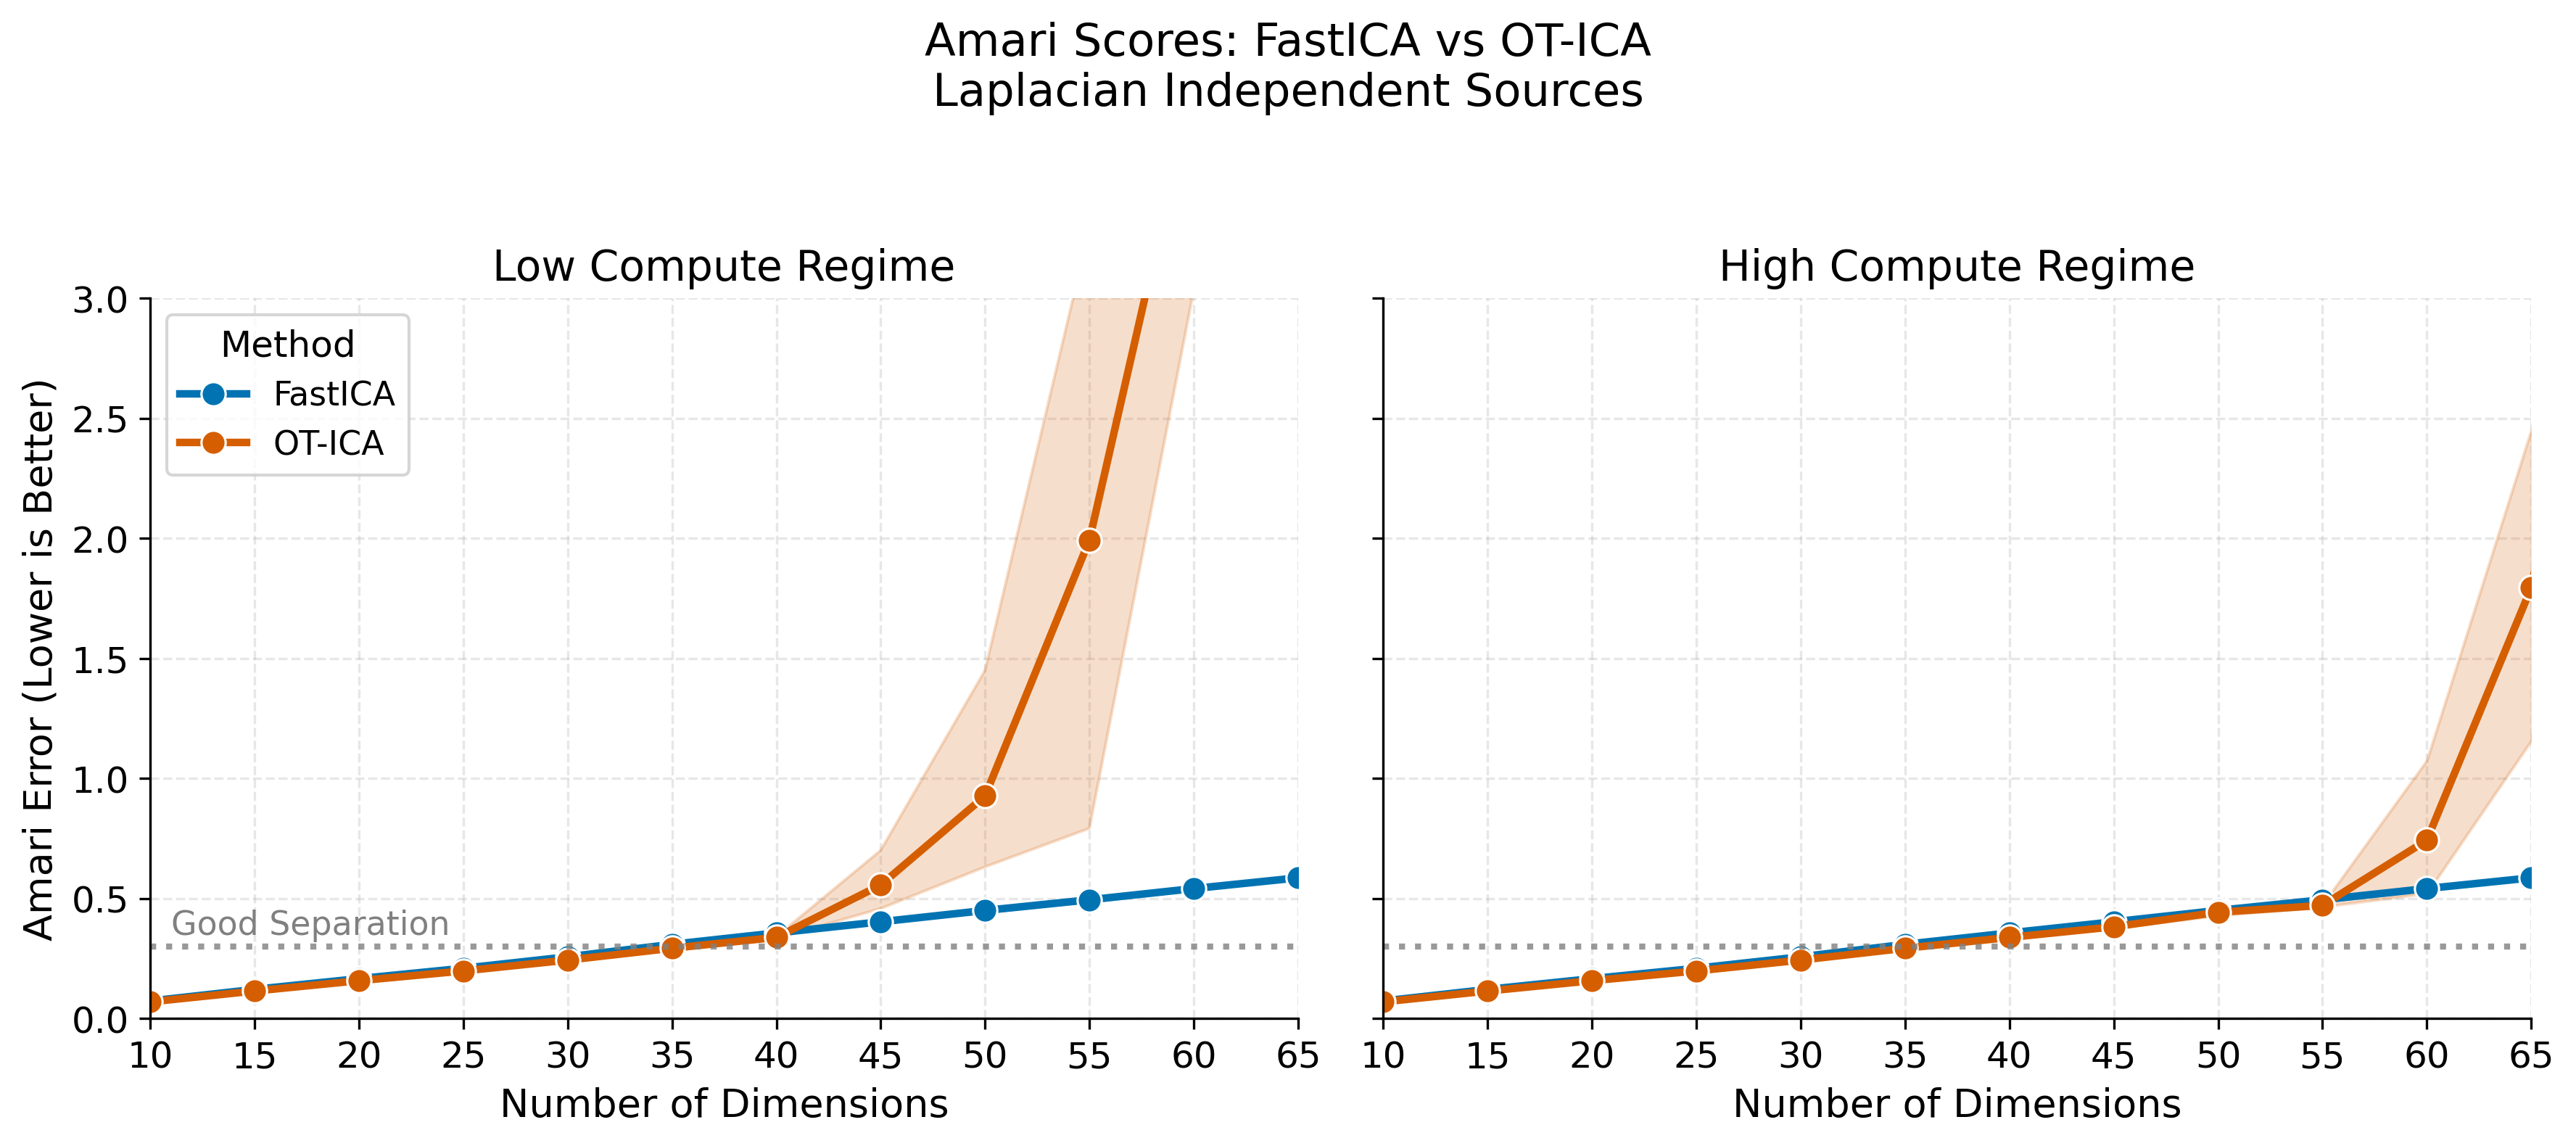

In [6]:
# ==========================================
# 4. Plot 1: Amari Error vs Dimension
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
palette = {'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}

for idx, comp in enumerate(COMPUTE_LEVELS):
    sns.lineplot(
        data=df[df['Compute Level'] == comp], x='Dimension', y='Amari Error', 
        hue='Method', palette=palette, marker='o', linewidth=2.5, markersize=8, ax=axes[idx]
    )
    axes[idx].set_title(f"{comp} Regime", fontsize=14)
    axes[idx].set_xlabel("Number of Dimensions", fontsize=13)
    axes[idx].set_xticks(DIMENSIONS)
    
    # --- NEW: Lock the x-axis maximum to 65 ---
    axes[idx].set_xlim(min(DIMENSIONS), 65)
    
    axes[idx].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)
    if idx == 0:
        axes[idx].set_ylabel("Amari Error (Lower is Better)", fontsize=13)
        axes[idx].text(min(DIMENSIONS)+1, 0.35, 'Good Separation', color='gray', fontsize=11)
        handles, labels = axes[idx].get_legend_handles_labels()
        axes[idx].legend(handles=handles, labels=labels, title='Method', loc='upper left')
    else:
        axes[idx].set_ylabel("")
        if axes[idx].get_legend(): axes[idx].get_legend().remove()

# --- Lock the y-axis strictly from 0 to 6 ---
plt.ylim(0, 3)

fig.suptitle("Amari Scores: FastICA vs OT-ICA\nLaplacian Independent Sources", fontsize=15, y=1.05)
plt.tight_layout()
#plt.savefig('laplace_amari_ot_ica_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

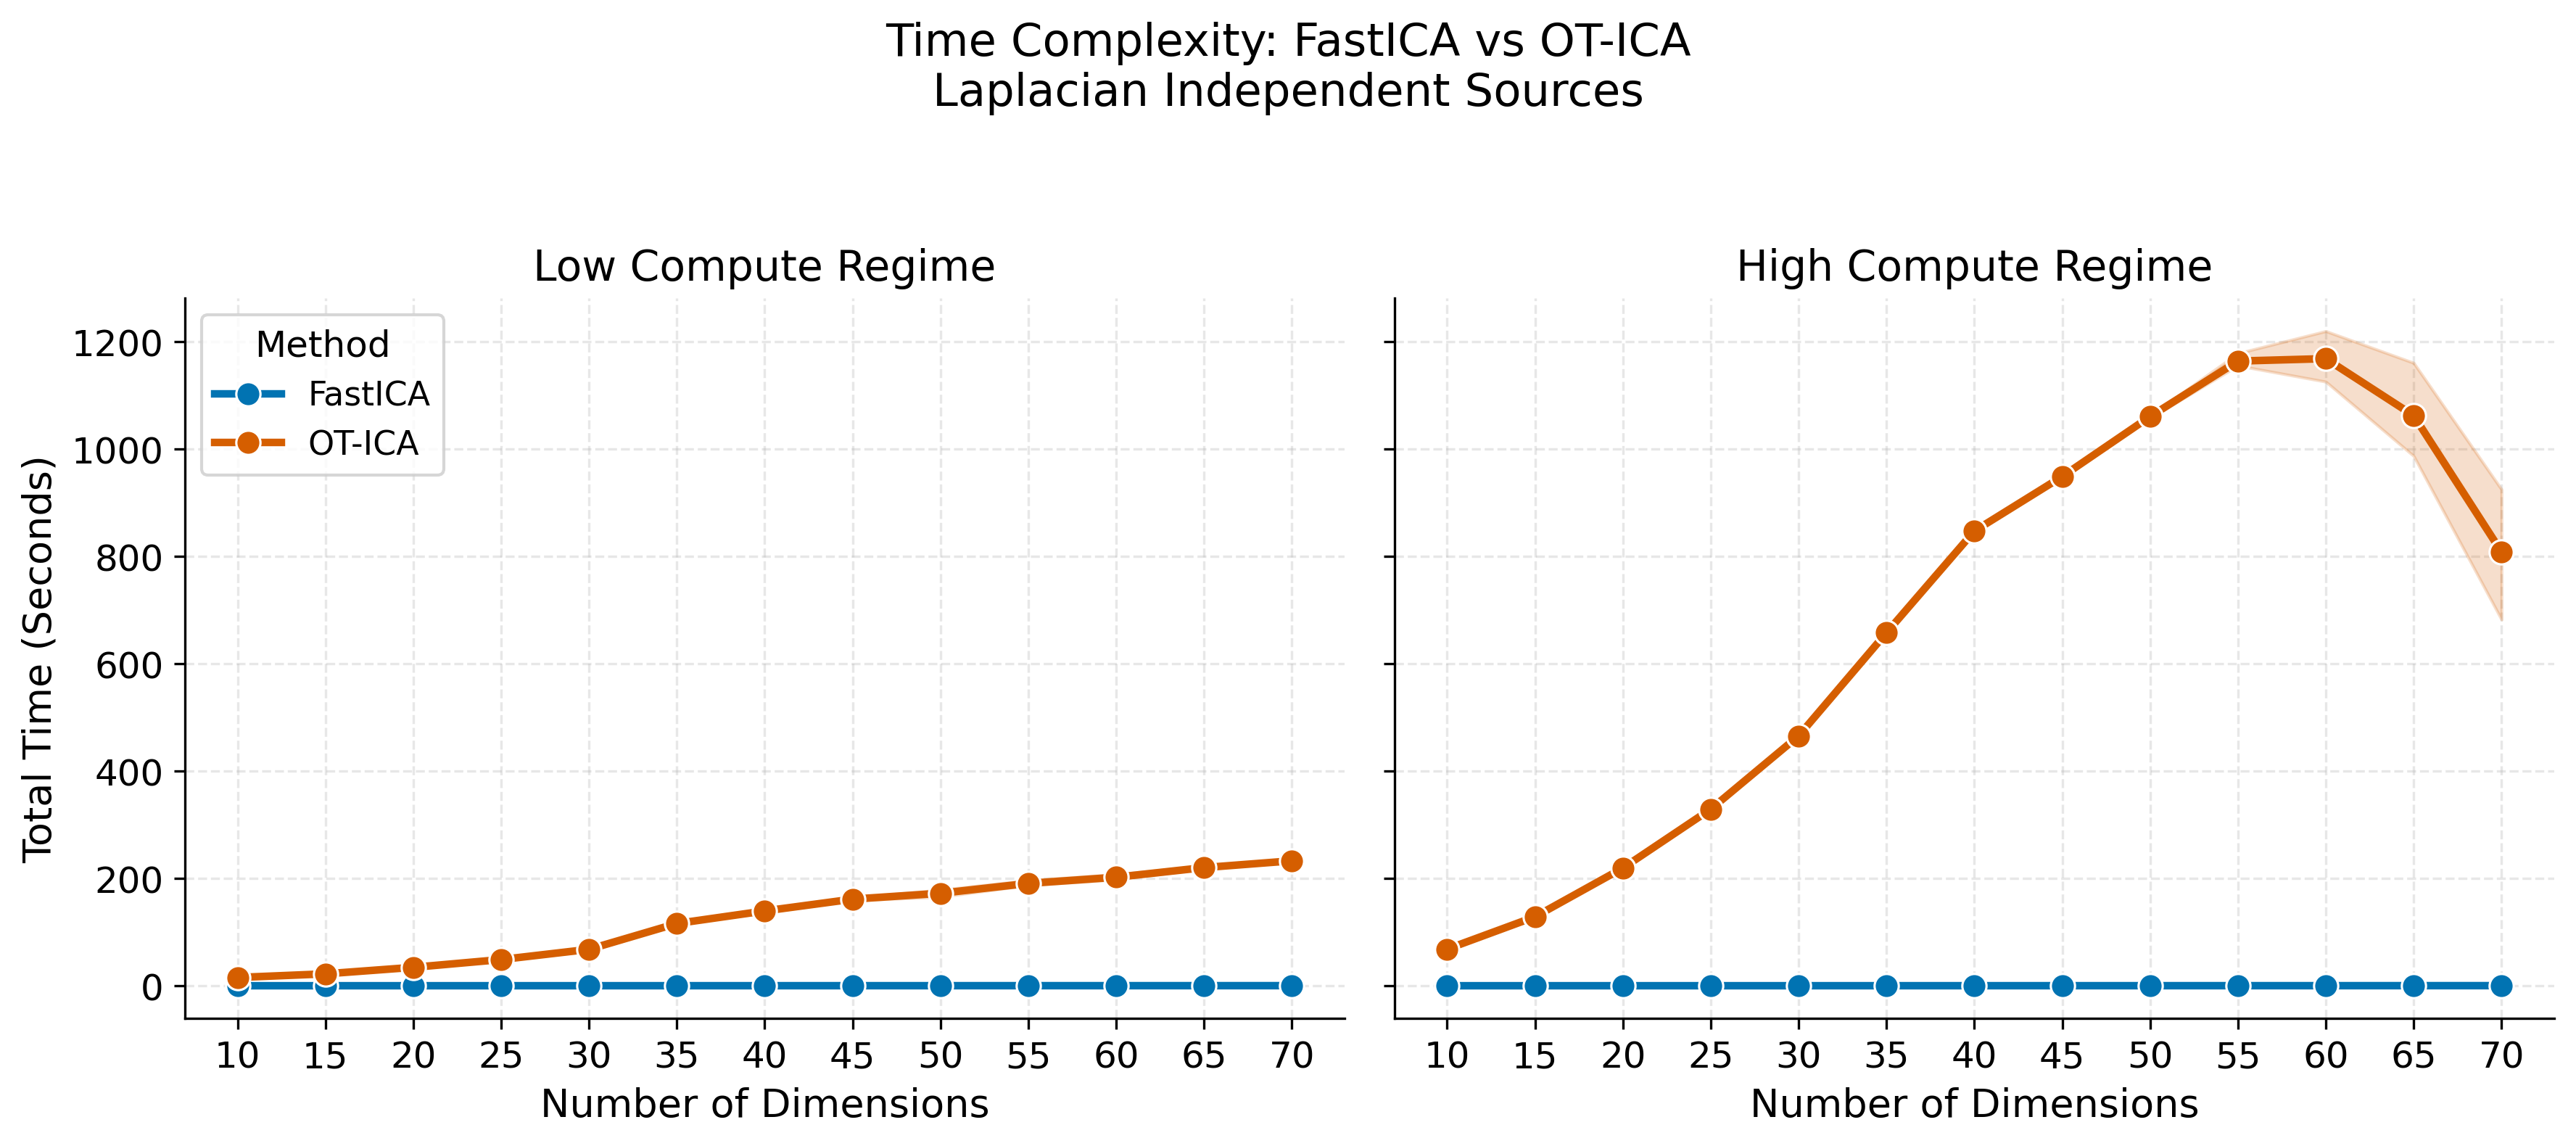


--- OT-ICA Time Breakdown ---


,Total Time (s)
Dimension,
10,41.85
15,75.36
20,126.80
25,188.93
30,266.72
35,386.91
40,493.37
45,555.18
50,616.52


In [7]:
# ==========================================
# 5. Plot 2: Total Execution Time vs Dimension
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

palette = {'FastICA': '#0173B2', 'OT-ICA': '#D55E00'}

# --- Subplot 1: Low Compute ---
df_low = df[df['Compute Level'] == 'Low Compute']
sns.lineplot(
    data=df_low, 
    x='Dimension', 
    y='Total Time (s)', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title("Low Compute Regime", fontsize=14)
axes[0].set_ylabel("Total Time (Seconds)", fontsize=13)
axes[0].set_xlabel("Number of Dimensions", fontsize=13)
axes[0].set_xticks(DIMENSIONS)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title='Method', loc='upper left', fontsize=11)

# --- Subplot 2: High Compute ---
df_high = df[df['Compute Level'] == 'High Compute']
sns.lineplot(
    data=df_high, 
    x='Dimension', 
    y='Total Time (s)', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)
axes[1].set_title("High Compute Regime", fontsize=14)
axes[1].set_ylabel("") # Shared y-axis
axes[1].set_xlabel("Number of Dimensions", fontsize=13)
axes[1].set_xticks(DIMENSIONS)

if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

fig.suptitle("Time Complexity: FastICA vs OT-ICA\nLaplacian Independent Sources", fontsize=15, y=1.05)
plt.tight_layout()
#plt.savefig('laplace_time_ot_ica_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

# Display time breakdown table for OT-ICA
otica_times = df[df['Method'] == 'OT-ICA'].groupby('Dimension')[['Total Time (s)']].mean()
print("\n--- OT-ICA Time Breakdown ---")
display(otica_times.round(2))

### What happens if we only do Stiefel step i.e. Phase 2, without Phase 1 with SGD? 

In [8]:
# ==========================================
# 1. Experiment Setup
# ==========================================
DIMENSIONS = [n for n in range(10, 21)]  # 10 to 20 dimensions
N_SAMPLES = 5000
N_TRIALS = 5  

print(f"--- FastICA vs. W-ICA (Stiefel Cold Start Only) ---")
print(f"Dimensions: {DIMENSIONS[0]} to {DIMENSIONS[-1]}")
print(f"Learning Rate: 0.1")

# ==========================================
# 2. Parallel Worker Function
# ==========================================
def run_cold_start_trial(dim, trial, n_samples):
    torch.set_num_threads(1) 
    trial_results = []
    
    # Generate standard Laplace data for a clear baseline
    X_torch, A_true = generate_dataset(n_dim=dim, n_samples=n_samples, seed=trial)
    X_np = X_torch.numpy()
    
    # --- FastICA (Baseline) ---
    t0_fast = time.perf_counter()
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
    t_fast_total = time.perf_counter() - t0_fast
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Amari Error': score_fast,
        'Time (s)': t_fast_total
    })
    
    # --- W-ICA (Phase 2 Stiefel Cold Start ONLY) ---
    t0_wass = time.perf_counter()
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        # We completely skip optimize_wasserstein2 (Phase 1)
        # Passing init_w=None forces optimize_symmetric to generate a random orthogonal matrix
        W_stiefel_cold = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=300,       # Slightly higher max_iter to account for the slower 0.1 LR
            lr=0.1,             # Your requested safe learning rate
            init_w=None,        # Cold Start trigger
            optimizer='stiefel',
        )
        
        W_wass_total = W_stiefel_cold.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W-ICA Error (dim {dim}, trial {trial}): {e}")
        score_wass = np.nan
        
    t_wass_total = time.perf_counter() - t0_wass
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'W-ICA (Cold Start)', 
        'Amari Error': score_wass,
        'Time (s)': t_wass_total
    })
    
    return trial_results

# ==========================================
# 3. Execute Main Loop
# ==========================================
tasks = [(dim, trial, N_SAMPLES) for dim in DIMENSIONS for trial in range(N_TRIALS)]

results_nested = Parallel(n_jobs=12)(
    delayed(run_cold_start_trial)(dim, trial, n_samples) 
    for dim, trial, n_samples in tqdm(tasks, desc="Running Cold Start Trials")
)

results = [item for sublist in results_nested for item in sublist]
df = pd.DataFrame(results)

display(df.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))

--- FastICA vs. W-ICA (Stiefel Cold Start Only) ---
Dimensions: 10 to 20
Learning Rate: 0.1


Running Cold Start Trials:   0%|          | 0/55 [00:00<?, ?it/s]

W-ICA Error (dim 10, trial 0): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 10, trial 1): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 10, trial 2): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 10, trial 3): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 10, trial 4): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 11, trial 0): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 11, trial 1): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 11, trial 2): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 11, trial 3): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 11, trial 4): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 12, trial 0): t() expects a tensor with <= 2 dimensions, but self is 3D
W-ICA Error (dim 12, 

Method,FastICA,W-ICA (Cold Start)
Dimension,,
10,0.1183,NaN
11,0.1281,NaN
12,0.1401,NaN
13,0.1550,NaN
14,0.1650,NaN
15,0.1771,NaN
16,0.1896,NaN
17,0.1997,NaN
18,0.2115,NaN


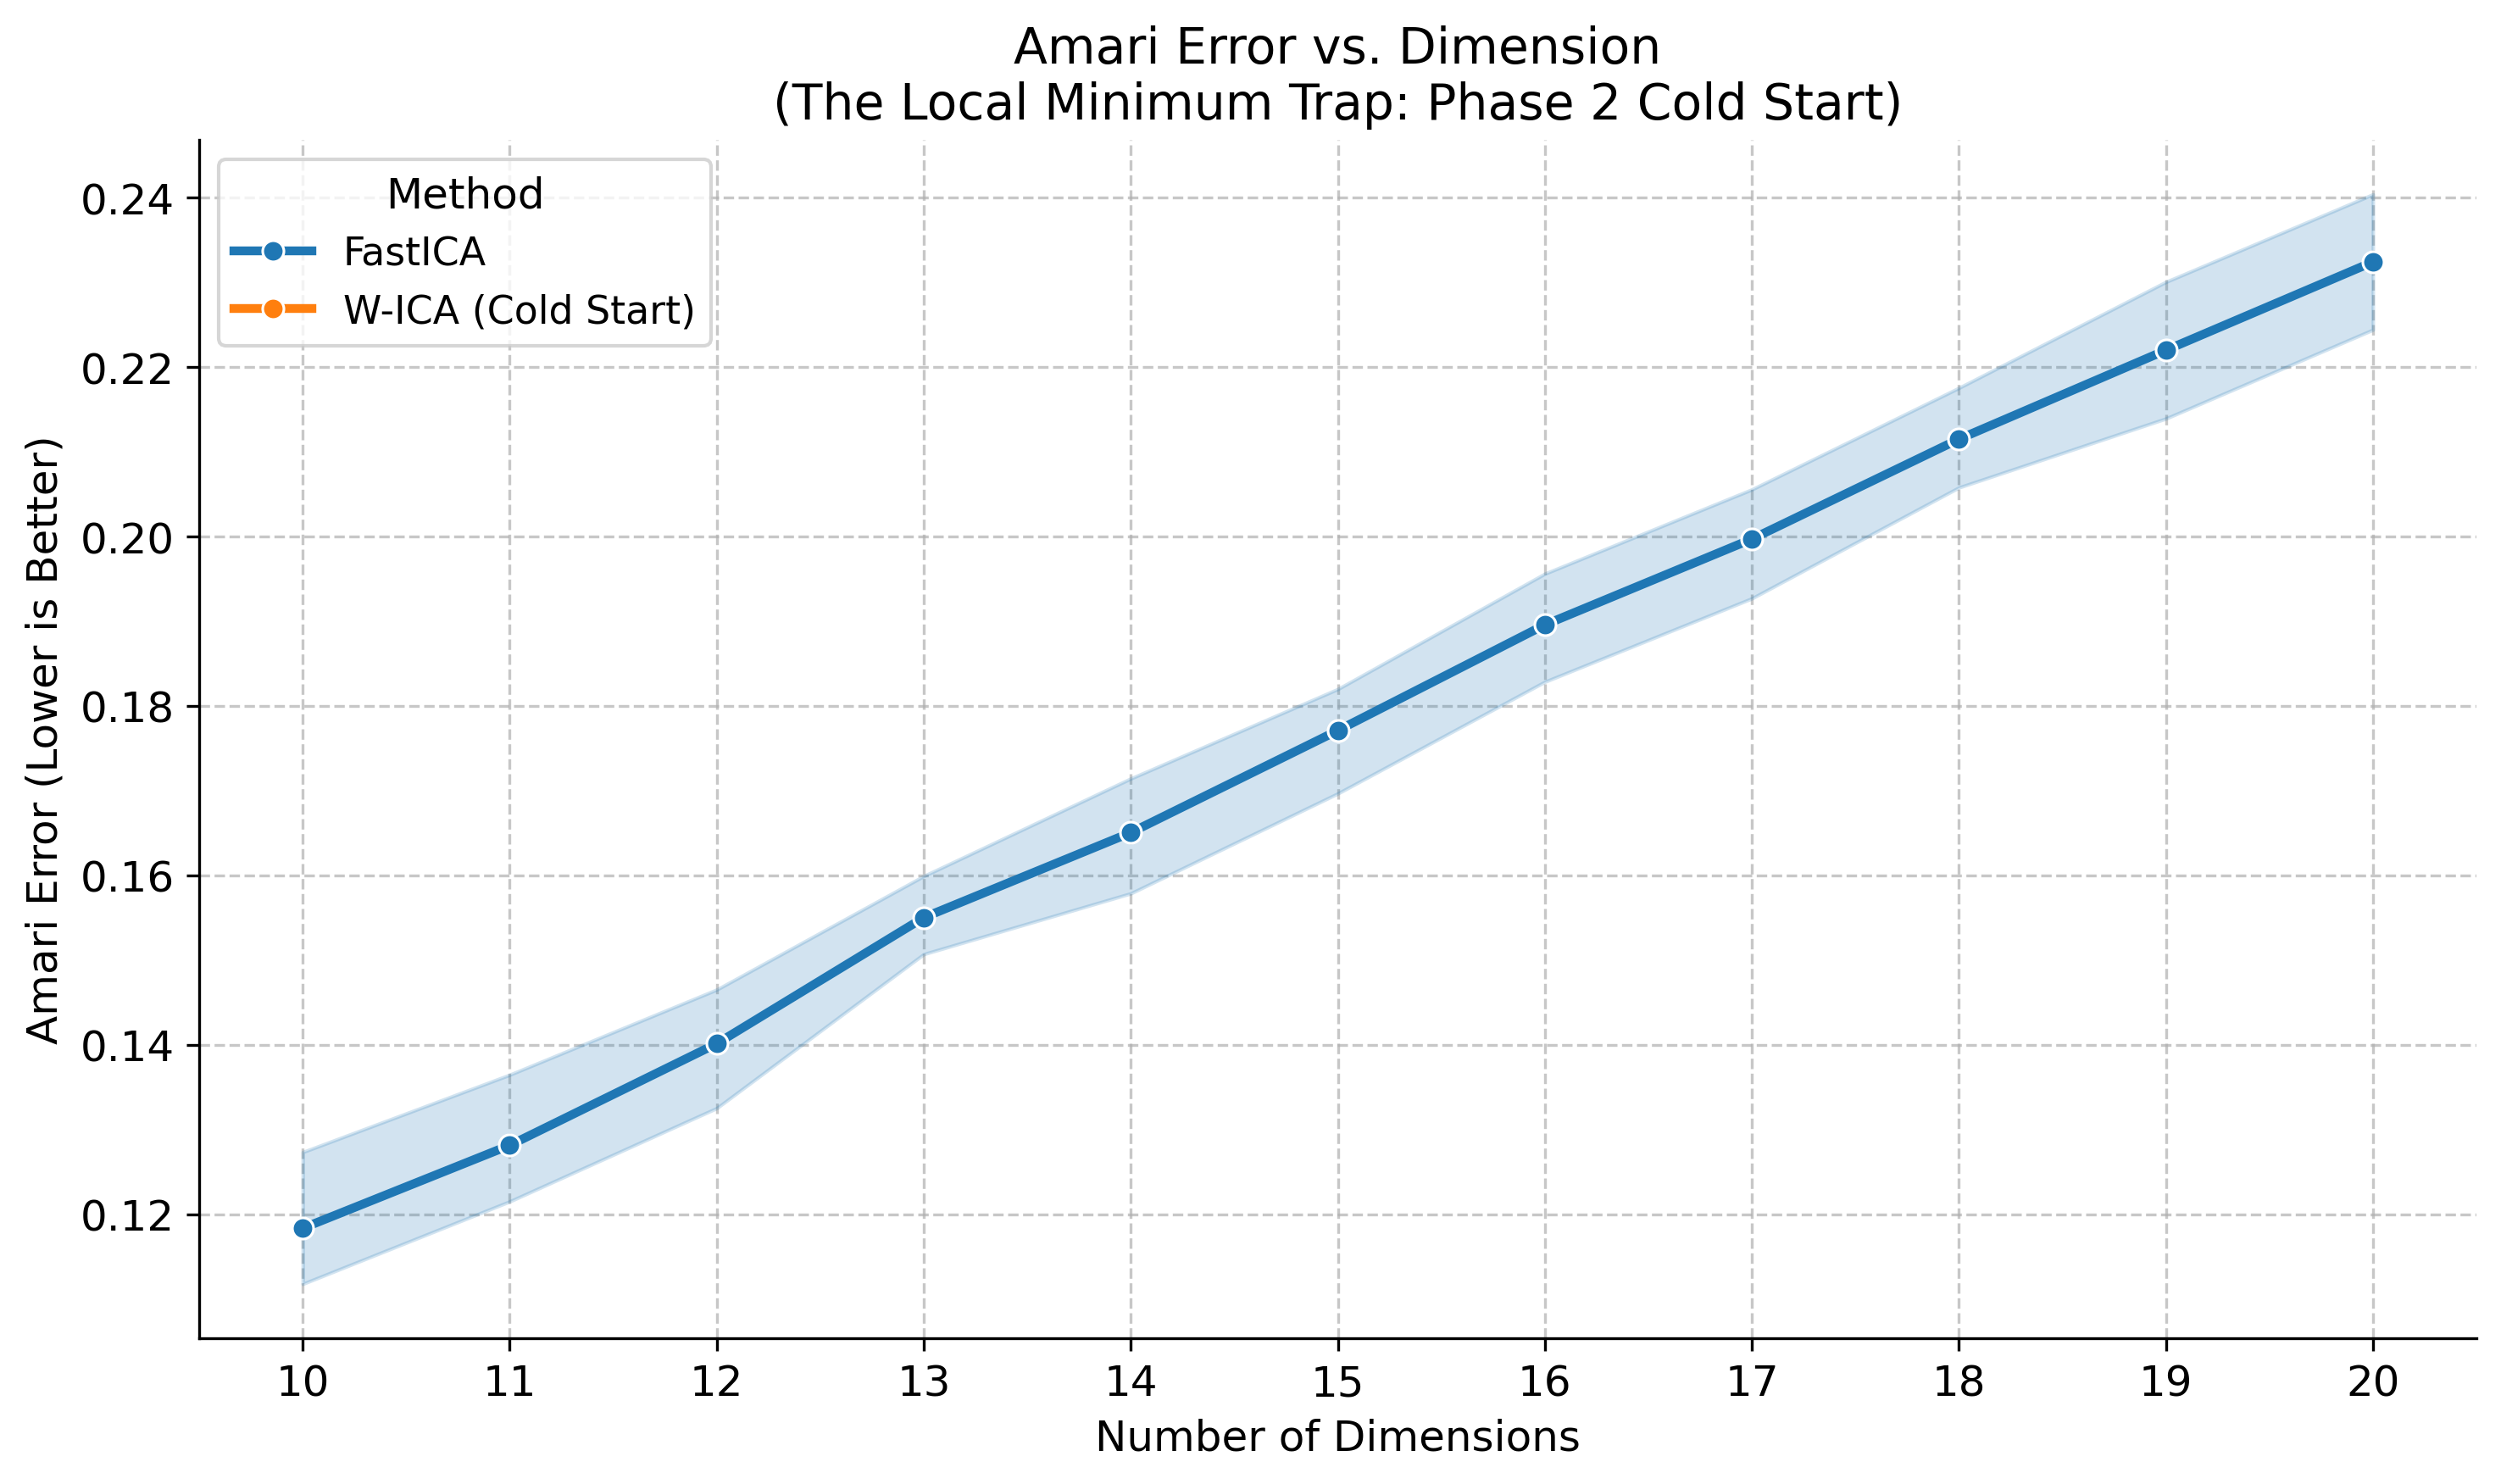

In [9]:
# ==========================================
# 4. Plotting the Cold Start Divergence
# ==========================================

plt.figure(figsize=(10, 6))

# Plot the Amari Error curves
sns.lineplot(
    data=df, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    marker='o', 
    linewidth=2.5,
    palette=['#1f77b4', '#ff7f0e'] # Force consistent colors (FastICA Blue, W-ICA Orange)
)

plt.title("Amari Error vs. Dimension\n(The Local Minimum Trap: Phase 2 Cold Start)", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.xticks(DIMENSIONS) # Ensure every dimension is ticked from 10 to 20
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()